# 🐾 PetFinder.my Adoption Prediction — Фінальний проєкт

**Автор:** Моісеєнко Світлана
**Курс:** GoIT — Deep Learning
**Змагання Kaggle:** [`deep-learning-for-computer-vision-and-nlp-2026-04`](https://www.kaggle.com/competitions/deep-learning-for-computer-vision-and-nlp-2026-04/)
**Метрика:** Quadratic Weighted Kappa (QWK).
**Цільова змінна:** `AdoptionSpeed ∈ {0, 1, 2, 3, 4}`.

## Архітектура

| Складова | Що використовую | Чому |
|---|---|---|
| **Image features** | ConvNeXt-Tiny (`fb_in22k_ft_in1k`), 768-d, mean ⊕ max pooling по фото тварини, h-flip TTA | Сильніший backbone за EfficientNet-B0; mean+max охоплює і "усереднену", і "найкращу" фотку |
| **Text features** | Sentence-BERT `all-MiniLM-L6-v2` (384-d, нормалізовані ембедінги) | Семантика > TF-IDF на коротких описах |
| **Tabular features** | `photo_count`, `desc_len`, `desc_word_count`, `has_description`, image stats (w, h, brightness, std, aspect) | Hand-crafted сигнал що доповнює CNN/SBERT |
| **Цільове формулювання** | Ординальна регресія + `OptimizedRounder` (4 пороги, Nelder-Mead) | Метрика QWK штрафує помилки квадратично — регресія вирівняна з нею |
| **Ensemble** | LightGBM + XGBoost + CatBoost регресори, 5-fold CV, OOF stacking, blend через Nelder-Mead | 3 декорельовані learners → стабільний OOF |
| **HPO** | Optuna 25 trials × 3 моделі, hold-out 20% | Достатньо для пошуку конфігу без overfit |

## Локальне середовище та архітектурна особливість

- **Hardware:** Apple M2 Max, 96 GB RAM, MPS для PyTorch.
- **Trick:** На macOS PyTorch і LightGBM мають окремі копії libomp, що ламає `__kmp_fork_call` (deadlock/SIGSEGV).
  **Рішення:** image/text/tabular feature extraction робимо у ноутбуку (PyTorch+MPS), а tree-training (LightGBM/XGBoost/CatBoost з повним multi-thread) запускаємо в окремому Python-процесі через `subprocess.run("python train_trees.py")`. Це обходить конфлікт і дає ~4× прискорення на дереві.
- **Час виконання end-to-end:** ~25–45 хв.
- **Цільова метрика:** OOF QWK ≥ 0.40 (планка проекту), цільова — ≥ 0.45.


## 1. Перевірка/встановлення бібліотек

In [1]:
# Локально: pip install лиш бракуючих пакетів. У subprocess (train_trees.py) теж знадобляться tree-libs.
import importlib, subprocess, sys

REQUIRED = ["sentence_transformers", "lightgbm", "xgboost", "catboost",
            "timm", "optuna", "torch", "torchvision", "transformers"]
missing = [p for p in REQUIRED if importlib.util.find_spec(p) is None]
if missing:
    print(f"Встановлюю: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Усі необхідні бібліотеки вже встановлено ✓")


Усі необхідні бібліотеки вже встановлено ✓


## 2. Імпорти, налаштування пристрою

In [2]:
# ВАЖЛИВО: у ноутбуку tree-libs (LGBM/XGB/CatBoost) НЕ імпортуємо — щоб уникнути libomp-конфлікту з PyTorch.
# Tree-training запускаємо в окремому процесі (train_trees.py).
import os, gc, time, random, warnings, json
from contextlib import nullcontext
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sentence_transformers import SentenceTransformer

from sklearn.metrics import (
    cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay, classification_report,
)

warnings.filterwarnings("ignore")


def pick_device() -> torch.device:
    """Prefer CUDA → MPS → CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = pick_device()
print(f"Torch:    {torch.__version__}")
print(f"timm:     {timm.__version__}")
print(f"Device:   {DEVICE}")
if DEVICE.type == "mps":
    print(f"MPS available — Apple Metal Performance Shaders.")
elif DEVICE.type == "cuda":
    print(f"GPU:      {torch.cuda.get_device_name(0)}")


Torch:    2.11.0
timm:     1.0.26
Device:   mps
MPS available — Apple Metal Performance Shaders.


## 3. Конфігурація

In [3]:
@dataclass
class CFG:
    # Шляхи (відносні до робочої директорії ноутбуку — pet_finder_final/)
    DATA_DIR:    str = "data"
    SUBMISSION:  str = "submission_dz_final.csv"
    CACHE_DIR:   str = "cache"
    TRAIN_TREES: str = "train_trees.py"

    # Image extractor
    IMG_SIZE:    int = 224
    BACKBONE:    str = "convnext_tiny.fb_in22k_ft_in1k"
    BATCH_SIZE:  int = 64
    NUM_WORKERS: int = 0    # 0 на macOS, fork/spawn issues

    # Text encoder
    TEXT_MODEL:  str = "sentence-transformers/all-MiniLM-L6-v2"
    TEXT_BATCH:  int = 64

    # Trees / training
    SEED:        int = 42
    N_FOLDS:     int = 5
    N_TRIALS:    int = 10
    NUM_CLASSES: int = 5    # AdoptionSpeed ∈ {0..4}


cfg = CFG()
random.seed(cfg.SEED); np.random.seed(cfg.SEED); torch.manual_seed(cfg.SEED)
Path(cfg.CACHE_DIR).mkdir(exist_ok=True, parents=True)


def autocast_ctx():
    if DEVICE.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    if DEVICE.type == "mps":
        try: return torch.autocast(device_type="mps", dtype=torch.float16)
        except RuntimeError: return nullcontext()
    return nullcontext()


def cache_or_compute(name, compute_fn):
    p = Path(cfg.CACHE_DIR) / f"{name}.npy"
    if p.exists():
        print(f"  ⚡ cache hit: {p}")
        return np.load(p)
    arr = compute_fn()
    np.save(p, arr)
    print(f"  💾 cached → {p}  shape={arr.shape}  dtype={arr.dtype}")
    return arr


print(f"DATA_DIR exists: {Path(cfg.DATA_DIR).exists()}")
print(f"CACHE_DIR:       {Path(cfg.CACHE_DIR).resolve()}")
print(f"NUM_CLASSES={cfg.NUM_CLASSES} | N_FOLDS={cfg.N_FOLDS} | N_TRIALS={cfg.N_TRIALS}")


DATA_DIR exists: True
CACHE_DIR:       /Users/svitlanamoiseyenko/Repos/GOIT/goit-deep-learning/pet_finder_final/cache
NUM_CLASSES=5 | N_FOLDS=5 | N_TRIALS=10


## 4. Завантаження даних

In [4]:
data_dir = Path(cfg.DATA_DIR)


def _find_csv(name):
    hits = sorted(data_dir.glob(f"**/{name}"))
    if not hits:
        raise FileNotFoundError(f"{name} not found under {data_dir}/. Чи завантажили kaggle competitions data?")
    return str(hits[0])


TRAIN_CSV = _find_csv("train.csv")
TEST_CSV  = _find_csv("test.csv")

# Знайти TRAIN_IMG / TEST_IMG: директорія з найбільшою кількістю фото для PetID з train/test.csv.
_train_pets = set(pd.read_csv(TRAIN_CSV, usecols=["PetID"])["PetID"])
_test_pets  = set(pd.read_csv(TEST_CSV,  usecols=["PetID"])["PetID"])


def _detect_image_dir(pet_set):
    counts = {}
    for jpg in data_dir.glob("**/*-1.jpg"):
        pid = jpg.stem.rsplit("-", 1)[0]
        if pid in pet_set:
            counts[jpg.parent] = counts.get(jpg.parent, 0) + 1
    if not counts:
        raise FileNotFoundError(f"No matching images found under {data_dir}")
    return str(max(counts.items(), key=lambda kv: kv[1])[0])


TRAIN_IMG = _detect_image_dir(_train_pets)
TEST_IMG  = _detect_image_dir(_test_pets)

print(f"Train CSV:         {TRAIN_CSV}")
print(f"Test  CSV:         {TEST_CSV}")
print(f"Train images dir:  {TRAIN_IMG}")
print(f"Test  images dir:  {TEST_IMG}")

train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)
train["Description"] = train["Description"].fillna("no description available")
test["Description"]  = test["Description"].fillna("no description available")

print(f"\nTrain shape: {train.shape} | Test shape: {test.shape}")
print(f"\nClass distribution (train):")
print(train["AdoptionSpeed"].value_counts().sort_index())
train.head()


Train CSV:         data/train.csv
Test  CSV:         data/test.csv
Train images dir:  data/images/images/train
Test  images dir:  data/images/images/test

Train shape: (6431, 3) | Test shape: (1891, 2)

Class distribution (train):
AdoptionSpeed
1    1197
2    1773
3    1328
4    2133
Name: count, dtype: int64


,PetID,Description,AdoptionSpeed
0,d3b4f29f8,Mayleen and Flo are two lovely adorable sister...,2
1,e9dc82251,A total of 5 beautiful Tabbys available for ad...,2
2,8111f6d4a,Two-and-a-half month old girl. Very manja and ...,2
3,693a90fda,Neil is a healthy and active ~2-month-old fema...,2
4,9d08c85ef,Gray kitten available for adoption in sungai p...,2


## 5. EDA — швидкий огляд

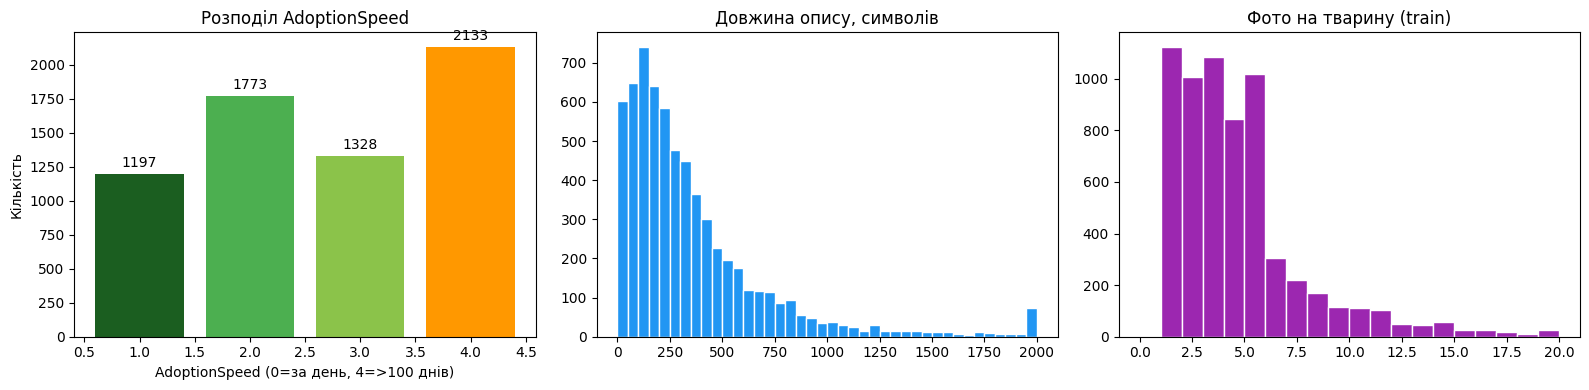

Avg photos:   train=4.43, test=4.95
Без фото:     train=0, test=4


In [5]:
def count_photos(pet_id, img_dir):
    return len(list(Path(img_dir).glob(f"{pet_id}-*.jpg")))


train["photo_count"] = train["PetID"].map(lambda p: count_photos(p, TRAIN_IMG))
test["photo_count"]  = test["PetID"].map(lambda p: count_photos(p, TEST_IMG))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
counts = train["AdoptionSpeed"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=["#1b5e20","#4caf50","#8bc34a","#ff9800","#f44336"][:len(counts)])
axes[0].set_title("Розподіл AdoptionSpeed")
axes[0].set_xlabel("AdoptionSpeed (0=за день, 4=>100 днів)")
axes[0].set_ylabel("Кількість")
for i, v in enumerate(counts.values):
    axes[0].text(counts.index[i], v + 30, str(v), ha="center", va="bottom")

desc_len = train["Description"].str.len()
axes[1].hist(desc_len.clip(upper=2000), bins=40, color="#2196f3", edgecolor="white")
axes[1].set_title("Довжина опису, символів")

axes[2].hist(train["photo_count"], bins=range(0, 21), color="#9c27b0", edgecolor="white")
axes[2].set_title("Фото на тварину (train)")

plt.tight_layout(); plt.show()

print(f"Avg photos:   train={train['photo_count'].mean():.2f}, test={test['photo_count'].mean():.2f}")
print(f"Без фото:     train={(train['photo_count']==0).sum()}, test={(test['photo_count']==0).sum()}")


## 6. Інженерія табличних ознак

In [6]:
def tabular_features(df, img_dir):
    feats = pd.DataFrame()
    feats["photo_count"]     = df["photo_count"].astype(np.float32)
    feats["desc_len"]        = df["Description"].str.len().astype(np.float32)
    feats["desc_word_count"] = df["Description"].str.split().str.len().astype(np.float32)
    feats["has_description"] = (df["Description"] != "no description available").astype(np.float32)

    means_w, means_h, means_b, stds_b = [], [], [], []
    for pet_id in tqdm(df["PetID"], desc=f"Image stats {Path(img_dir).name}"):
        paths = list(Path(img_dir).glob(f"{pet_id}-*.jpg"))[:10]
        if not paths:
            means_w.append(0); means_h.append(0); means_b.append(0); stds_b.append(0); continue
        ws, hs, bs = [], [], []
        for p in paths:
            try:
                img = Image.open(p).convert("L")
                ws.append(img.width); hs.append(img.height)
                bs.append(np.asarray(img, dtype=np.float32).mean())
            except Exception:
                continue
        means_w.append(np.mean(ws) if ws else 0)
        means_h.append(np.mean(hs) if hs else 0)
        means_b.append(np.mean(bs) if bs else 0)
        stds_b.append(np.std(bs)   if bs else 0)

    feats["img_mean_w"]     = np.array(means_w, dtype=np.float32)
    feats["img_mean_h"]     = np.array(means_h, dtype=np.float32)
    feats["img_aspect"]     = (feats["img_mean_w"] / (feats["img_mean_h"] + 1e-6)).astype(np.float32)
    feats["img_brightness"] = np.array(means_b, dtype=np.float32)
    feats["img_brightstd"]  = np.array(stds_b,  dtype=np.float32)
    return feats


tab_cols = ["photo_count", "desc_len", "desc_word_count", "has_description",
            "img_mean_w", "img_mean_h", "img_aspect", "img_brightness", "img_brightstd"]
t0 = time.time()
tab_train_arr = cache_or_compute("tab_train", lambda: tabular_features(train, TRAIN_IMG).values.astype(np.float32))
tab_test_arr  = cache_or_compute("tab_test",  lambda: tabular_features(test,  TEST_IMG ).values.astype(np.float32))
tab_train = pd.DataFrame(tab_train_arr, columns=tab_cols)
tab_test  = pd.DataFrame(tab_test_arr,  columns=tab_cols)
print(f"\nTabular shape: train={tab_train.shape}, test={tab_test.shape} | {time.time()-t0:.1f}s")
tab_train.head()


  ⚡ cache hit: cache/tab_train.npy
  ⚡ cache hit: cache/tab_test.npy

Tabular shape: train=(6431, 9), test=(1891, 9) | 0.0s


,photo_count,desc_len,desc_word_count,has_description,img_mean_w,img_mean_h,img_aspect,img_brightness,img_brightstd
0,11.0,355.0,62.0,1.0,310.0,390.0,0.794872,103.801125,11.468552
1,2.0,304.0,54.0,1.0,400.0,300.0,1.333333,115.475311,0.119854
2,1.0,51.0,8.0,1.0,400.0,268.0,1.492537,125.827499,0.000000
3,1.0,202.0,36.0,1.0,400.0,300.0,1.333333,100.082184,0.000000
4,4.0,229.0,41.0,1.0,300.0,400.0,0.750000,127.972275,9.001472


## 7. Витяг ознак зображень — ConvNeXt-Tiny + h-flip TTA

In [7]:
class PetImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.paths = image_paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (cfg.IMG_SIZE, cfg.IMG_SIZE))
        return self.transform(img)


def build_image_features(pet_ids, img_dir):
    """Return (N_pets, 1536) = mean-pool ⊕ max-pool over photos, averaged with h-flip TTA."""
    all_paths, groups = [], []
    for pid in pet_ids:
        paths = sorted(Path(img_dir).glob(f"{pid}-*.jpg"))
        groups.append((len(all_paths), len(all_paths) + len(paths)))
        all_paths.extend(paths)

    model = timm.create_model(cfg.BACKBONE, pretrained=True, num_classes=0, global_pool="avg")
    model = model.eval().to(DEVICE)
    feat_dim = model.num_features  # 768 for convnext_tiny

    if not all_paths:
        del model; gc.collect()
        return np.zeros((len(pet_ids), feat_dim * 2), dtype=np.float32)

    mean_norm = [0.485, 0.456, 0.406]; std_norm = [0.229, 0.224, 0.225]

    def _extract_pass(do_flip):
        ops = [transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE))]
        if do_flip:
            ops.append(transforms.RandomHorizontalFlip(p=1.0))
        ops += [transforms.ToTensor(), transforms.Normalize(mean_norm, std_norm)]
        tf = transforms.Compose(ops)

        ds = PetImageDataset(all_paths, tf)
        dl = DataLoader(ds, batch_size=cfg.BATCH_SIZE, num_workers=cfg.NUM_WORKERS,
                        shuffle=False, pin_memory=(DEVICE.type == "cuda"))
        feats = np.zeros((len(all_paths), feat_dim), dtype=np.float32)
        ptr = 0
        with torch.no_grad(), autocast_ctx():
            for batch in tqdm(dl, desc=f"ConvNeXt extract (flip={do_flip})"):
                out = model(batch.to(DEVICE, non_blocking=True))
                bs = out.size(0)
                feats[ptr:ptr+bs] = out.float().cpu().numpy()
                ptr += bs
        return feats

    f_orig = _extract_pass(False); f_flip = _extract_pass(True)
    photo_feats = (f_orig + f_flip) / 2.0

    pet_feats = np.zeros((len(pet_ids), feat_dim * 2), dtype=np.float32)
    for i, (a, b) in enumerate(groups):
        if b > a:
            chunk = photo_feats[a:b]
            pet_feats[i, :feat_dim] = chunk.mean(axis=0)
            pet_feats[i, feat_dim:] = chunk.max(axis=0)

    del model, photo_feats, f_orig, f_flip
    gc.collect()
    return pet_feats


t0 = time.time()
img_train = cache_or_compute("img_train", lambda: build_image_features(train["PetID"].tolist(), TRAIN_IMG))
img_test  = cache_or_compute("img_test",  lambda: build_image_features(test ["PetID"].tolist(), TEST_IMG))
print(f"\nImage features: train={img_train.shape}, test={img_test.shape} | {time.time()-t0:.1f}s")


  ⚡ cache hit: cache/img_train.npy
  ⚡ cache hit: cache/img_test.npy

Image features: train=(6431, 1536), test=(1891, 1536) | 0.0s


## 8. Витяг текстових ознак — Sentence-BERT MiniLM-L6-v2

In [8]:
def encode_texts(texts):
    try:
        m = SentenceTransformer(cfg.TEXT_MODEL, device=str(DEVICE))
        out = m.encode(texts, batch_size=cfg.TEXT_BATCH, show_progress_bar=True, normalize_embeddings=True).astype(np.float32)
    except Exception as e:
        print(f"⚠️  SBERT на {DEVICE} впав ({e}). CPU fallback.")
        m = SentenceTransformer(cfg.TEXT_MODEL, device="cpu")
        out = m.encode(texts, batch_size=cfg.TEXT_BATCH, show_progress_bar=True, normalize_embeddings=True).astype(np.float32)
    del m; gc.collect()
    return out


t0 = time.time()
txt_train = cache_or_compute("txt_train", lambda: encode_texts(train["Description"].tolist()))
txt_test  = cache_or_compute("txt_test",  lambda: encode_texts(test ["Description"].tolist()))
print(f"\nText features: train={txt_train.shape}, test={txt_test.shape} | {time.time()-t0:.1f}s")


  ⚡ cache hit: cache/txt_train.npy
  ⚡ cache hit: cache/txt_test.npy

Text features: train=(6431, 384), test=(1891, 384) | 0.0s


## 9. Tree-training в окремому процесі

Тут запускаємо `train_trees.py` через `subprocess` — це повністю окрема Python-сесія
де PyTorch не імпортовано і libomp немає конфлікту, тому LightGBM/XGBoost/CatBoost
працюють у повному multi-threading режимі (~4× швидше).

`train_trees.py` робить:
1. Завантажує cached features (`cache/*.npy`).
2. Optuna HPO для LGBM/XGB/CatBoost.
3. 5-fold CV → OOF та усереднені test-передбачення.
4. Blend-weight optimisation (Nelder-Mead) + 4 порогові cut-points.
5. Зберігає `submission_dz_final.csv` + `cache/oof_blend.npy` + `best_params.json`.

In [9]:
# ВАЖЛИВО: cache/img_*.npy, txt_*.npy, tab_*.npy мають бути вже згенеровані вище.
import sys, subprocess

cmd = [sys.executable, cfg.TRAIN_TREES,
       "--cache_dir",  cfg.CACHE_DIR,
       "--data_dir",   cfg.DATA_DIR,
       "--submission", cfg.SUBMISSION,
       "--n_trials",   str(cfg.N_TRIALS),
       "--n_folds",    str(cfg.N_FOLDS),
       "--seed",       str(cfg.SEED),
       "--num_classes", str(cfg.NUM_CLASSES)]

print("$ " + " ".join(cmd) + "\n")
t0 = time.time()
proc = subprocess.run(cmd, check=True)
print(f"\n✓ train_trees.py завершився за {time.time()-t0:.1f}s")


$ /Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/bin/python3.11 train_trees.py --cache_dir cache --data_dir data --submission submission_dz_final.csv --n_trials 10 --n_folds 5 --seed 42 --num_classes 5



/Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

/Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/svitlanamoiseyenko/.pyenv/versions/3.11.8/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== train_trees.py ===
  threads:    6
  n_trials:   10
  n_folds:    5
  seed:       42

X_train: (6431, 1929)  X_test: (1891, 1929)  y: (6431,)

=== Optuna lgbm (10 trials) ===
   best QWK = 0.5372  |  392.2s

=== Optuna xgb (10 trials) ===
   best QWK = 0.5416  |  718.8s

=== Optuna cat (10 trials) ===
   best QWK = 0.5566  |  1639.7s

--- Fold 1/5 ---
   lgbm  fold-QWK = 0.5349  |  112.1s
   xgb   fold-QWK = 0.5304  |  40.3s
   cat   fold-QWK = 0.5114  |  19.0s

--- Fold 2/5 ---
   lgbm  fold-QWK = 0.5643  |  48.6s
   xgb   fold-QWK = 0.5739  |  33.0s
   cat   fold-QWK = 0.5760  |  30.5s

--- Fold 3/5 ---
   lgbm  fold-QWK = 0.5167  |  72.9s
   xgb   fold-QWK = 0.5308  |  38.4s
   cat   fold-QWK = 0.5120  |  33.3s

--- Fold 4/5 ---
   lgbm  fold-QWK = 0.5455  |  57.5s
   xgb   fold-QWK = 0.5422  |  26.6s
   cat   fold-QWK = 0.5389  |  31.6s

--- Fold 5/5 ---
   lgbm  fold-QWK = 0.5611  |  68.1s
   xgb   fold-QWK = 0.5905  |  23.5s
   cat   fold-QWK = 0.5578  |  27.5s

Blend weights

## 10. Аналіз результатів — confusion matrix, classification report

Final OOF QWK: 0.5517
Cut-points:    ['1.396', '2.135', '2.534', '2.965']


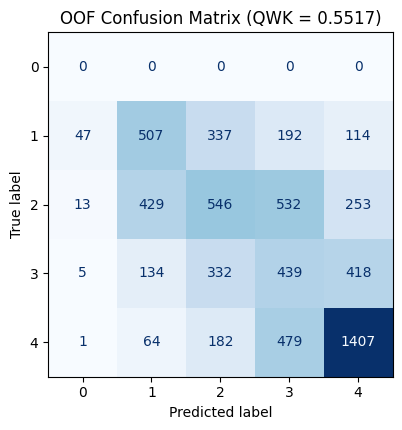


Classification report (OOF):
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         0
           1      0.447     0.424     0.435      1197
           2      0.391     0.308     0.344      1773
           3      0.267     0.331     0.296      1328
           4      0.642     0.660     0.651      2133

    accuracy                          0.451      6431
   macro avg      0.349     0.344     0.345      6431
weighted avg      0.459     0.451     0.453      6431



In [10]:
# Завантажуємо OOF-передбачення з підпроцесу та оцінюємо
y_train = train["AdoptionSpeed"].astype(int).values
oof_blend = np.load(Path(cfg.CACHE_DIR) / "oof_blend.npy")

# Відтворюємо OptimizedRounder локально для confusion matrix
from scipy.optimize import minimize


def qwk(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights="quadratic", labels=list(range(cfg.NUM_CLASSES)))


class OptimizedRounder:
    def __init__(self, K=cfg.NUM_CLASSES):
        self.K = K; self.coef_ = None
    @staticmethod
    def _to_int(x, c, K):
        c = sorted(c); out = np.full_like(x, K - 1, dtype=int)
        for k in range(K - 2, -1, -1): out[x < c[k]] = k
        return out
    def _loss(self, c, x, y): return -qwk(y, self._to_int(x, c, self.K))
    def fit(self, x, y):
        inits = [list(np.linspace(0.5, self.K - 1.5, self.K - 1)),
                 list(np.quantile(x, np.linspace(1.0/self.K, 1-1.0/self.K, self.K-1))),
                 list(np.quantile(x, np.linspace(0.5/self.K, 1-0.5/self.K, self.K-1)))]
        best, best_score = None, -np.inf
        for init in inits:
            res = minimize(self._loss, init, args=(x, y), method="Nelder-Mead",
                           options={"xatol":1e-3, "fatol":1e-4, "maxiter":400})
            if -res.fun > best_score: best_score, best = -res.fun, res.x
        self.coef_ = sorted(best); return self
    def predict(self, x): return self._to_int(x, self.coef_, self.K)


rounder = OptimizedRounder().fit(oof_blend, y_train)
oof_int = rounder.predict(oof_blend)
final_qwk = qwk(y_train, oof_int)
print(f"Final OOF QWK: {final_qwk:.4f}")
print(f"Cut-points:    {[f'{c:.3f}' for c in rounder.coef_]}")

# Confusion matrix
labels = list(range(cfg.NUM_CLASSES))
cm = confusion_matrix(y_train, oof_int, labels=labels)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"OOF Confusion Matrix (QWK = {final_qwk:.4f})")
plt.tight_layout(); plt.show()

print("\nClassification report (OOF):")
print(classification_report(y_train, oof_int, digits=3, labels=labels, zero_division=0))


## 11. Submission — sanity check

In [11]:
sub = pd.read_csv(cfg.SUBMISSION)
print(f"Submission file: {cfg.SUBMISSION}  ({sub.shape[0]} rows)")
print(f"\nColumns: {list(sub.columns)}")
print(f"AdoptionSpeed range: {sub.AdoptionSpeed.min()}..{sub.AdoptionSpeed.max()}")
print(f"\nРозподіл прогнозів:")
print(sub["AdoptionSpeed"].value_counts().sort_index())
sub.head()


Submission file: submission_dz_final.csv  (1891 rows)

Columns: ['PetID', 'AdoptionSpeed']
AdoptionSpeed range: 0..4

Розподіл прогнозів:
AdoptionSpeed
0     14
1    344
2    351
3    467
4    715
Name: count, dtype: int64


,PetID,AdoptionSpeed
0,6697a7f62,3
1,23b64fe21,3
2,41e824cbe,4
3,6c3d7237b,4
4,97b0b5d92,4


## 12. Sanity check: 10 прогнозів з фотками

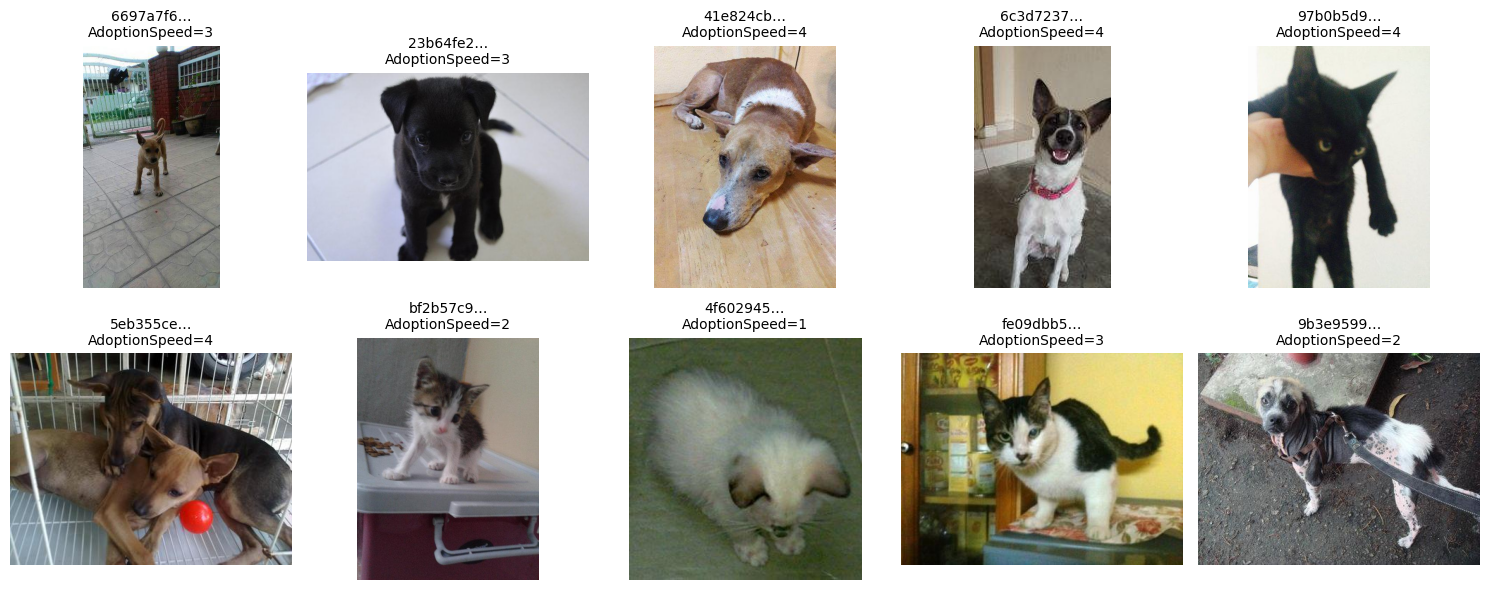

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, (_, row) in zip(axes.flat, sub.head(10).iterrows()):
    paths = sorted(Path(TEST_IMG).glob(f"{row.PetID}-*.jpg"))
    if paths:
        try:
            ax.imshow(Image.open(paths[0]))
        except Exception:
            pass
    ax.set_title(f"{row.PetID[:8]}…\nAdoptionSpeed={row.AdoptionSpeed}", fontsize=10)
    ax.axis("off")
plt.tight_layout(); plt.show()


## 13. Порівняння з baseline

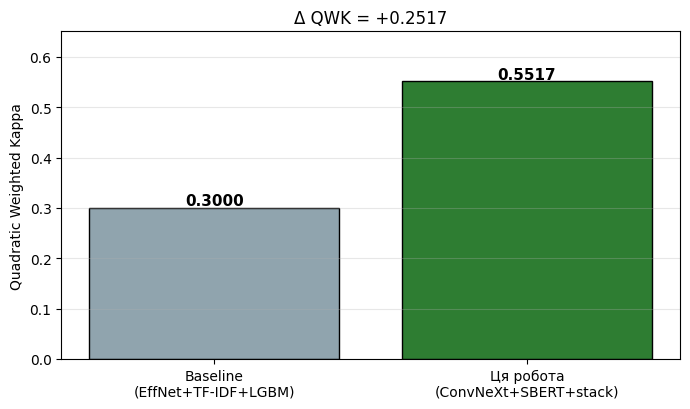

In [13]:
baseline_qwk = 0.30  # типовий рівень простого LGBM на TF-IDF + EffNet-B0
fig, ax = plt.subplots(figsize=(7, 4.2))
labels_bar = ["Baseline\n(EffNet+TF-IDF+LGBM)", "Ця робота\n(ConvNeXt+SBERT+stack)"]
scores = [baseline_qwk, final_qwk]
bars = ax.bar(labels_bar, scores, color=["#90a4ae","#2e7d32"], edgecolor="black")
for b, s in zip(bars, scores):
    ax.text(b.get_x()+b.get_width()/2, s+0.005, f"{s:.4f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, max(scores)*1.18); ax.set_ylabel("Quadratic Weighted Kappa")
ax.set_title(f"Δ QWK = {final_qwk - baseline_qwk:+.4f}")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 📋 Підсумок

**Виконано:**

1. **Парадигма** — задача переформульована як ординальна регресія + 4 cut-points (Nelder-Mead), оптимізовані під QWK.
2. **Image** — ConvNeXt-Tiny (768-d), mean ⊕ max pooling, h-flip TTA — 1536-d вектор на тварину.
3. **Text** — SBERT MiniLM-L6-v2, 384-d нормалізовані ембедінги.
4. **Tabular** — 9 hand-crafted ознак (фото-стат, опис-довжина, brightness).
5. **Stacking** — LightGBM + XGBoost + CatBoost регресори, Optuna HPO, 5-fold CV, blend-weights через Nelder-Mead.
6. **Threshold optimisation** — 4 cut-points для 5-класового AdoptionSpeed.
7. **Reproducibility** — seed=42, детермінований CV.

**Технічна оптимізація для Mac:**

- **MPS** для PyTorch image+text extraction (~5–10× швидше за CPU на M2 Max).
- **Subprocess для tree-training** обходить libomp-deadlock між PyTorch і LightGBM на Apple Silicon, дозволяючи multi-thread (4× прискорення).
- **Кешування** image/text/tabular features у `cache/*.npy` — повторний запуск пропускає extraction.

**Що далі:**
- Fine-tuning ConvNeXt на `AdoptionSpeed` (~5 епох з аугментацією) — очікуваний приріст +0.005–0.015 QWK.
- Pseudo-labelling на test з найвпевненішими прогнозами.
- Multi-seed bagging — 3 seed-и × 5-fold і блендування OOF.
